In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
import h5py
import pandas as pd
from scipy.optimize import curve_fit
from uniformity_fit import *
from flatness import *
import tifffile as tiff


In [ ]:
def beam_centroid(img,):
    # coordinate grids
    y, x = np.indices(img.shape)

    I = img.astype(float)

    total_intensity = np.nansum(I)

    if total_intensity == 0:
        return None, None  # or fallback to max pixel

    x_centroid = np.nansum(I * x) / total_intensity
    y_centroid = np.nansum(I * y) / total_intensity


    return int(x_centroid), int(y_centroid)

def beam_area_mask(img, fraction, cx,cy):
    peak_val = np.nanmax(img)
    threshold = fraction * peak_val

    # mask of pixels above threshold
    mask = img >= threshold

    return mask

def plot_dose1(dosemap, im_type):
    h, w = dosemap.shape
    strip_width = 10

    if im_type == 'RCF':
        pixel_calibration = 0.08467  # mm/pixel
    elif im_type == "YAG":
        pixel_calibration = 27.9/ (1680-800)
    else:
        raise ValueError("Unknown im_type")

    # Beam centroid in pixel coordinates
    cx, cy = beam_centroid(dosemap)

    # Centered physical coordinates in mm
    x = (np.arange(w) - cx) * pixel_calibration
    y = (np.arange(h) - cy) * pixel_calibration

    dx = np.mean(np.diff(x))
    dy = np.mean(np.diff(y))

    # Use integer indices for slicing
    row0 = max(0, cy - strip_width // 2)
    row1 = min(h, cy + strip_width // 2)
    col0 = max(0, cx - strip_width // 2)
    col1 = min(w, cx + strip_width // 2)

    slice_row = np.mean(dosemap[row0:row1, :], axis=0)
    slice_col = np.mean(dosemap[:, col0:col1], axis=1)

    fig, ax_main = plt.subplots(figsize=(10, 6))

    # Image centered at (0, 0)
    im = ax_main.imshow(
        dosemap,
        origin="lower",
        aspect="equal",
        cmap="viridis",
        extent=[x[0], x[-1], y[0], y[-1]]
    )

    # Beam mask and contour
    mask = beam_area_mask(dosemap, 0.85, cx, cy)
    # if im_type == 'YAG':
        # ax_main.contour(x, y, mask.astype(float), levels=[0.5], colors='white', linewidths=1.6)

    ax_main.set_xlabel("X (mm)")
    ax_main.set_ylabel("Y (mm)")

    # Axes for slices and colorbar
    divider = make_axes_locatable(ax_main)
    ax_x = divider.append_axes("top", size="25%", pad=0.1, sharex=ax_main)
    ax_y = divider.append_axes("right", size="20%", pad=0.1, sharey=ax_main)
    cax  = divider.append_axes("right", size="2%", pad=0.1)

    # Fit the slices
    p0 = [np.max(slice_row)/2, 0, 5, 2,0,0]
    p00 = [np.max(slice_row),  6, 3,-1,0,0]


    params_x, _ = curve_fit(supergaussian1D_skewed, x, slice_row, p0=p0)
    params_y, _ = curve_fit(supergaussian1D_skewed, y, slice_col, p0=p0)

    params_xx, _ = curve_fit(sum_2gaussians_skewed, x, slice_row, p0=p00)
    params_yy, _ = curve_fit(sum_2gaussians_skewed, y, slice_col, p0=p00)
    sig_x, sig_y = params_x[2], params_y[2]
    P_x, P_y = params_x[3], params_y[3]
    x90_x, x90_y = abs(x90(sig_x, P_x)), abs(x90(sig_y, P_y))

    # Top plot: X slice
    ax_x.bar(x, slice_row, width=dx, alpha=0.7)
    
    ax_x.plot( x,supergaussian1D_skewed(x, *params_x),  'r-',label=f"SuperGaussian Fit (P={params_x[3]:.2f}, x90={x90_x:.2f})")
    ax_x.plot(x, sum_2gaussians_skewed(x, *params_xx), 'b-', label=f"2-Gaussian Fit (x0/sigma={abs(params_xx[1])/params_xx[2]:.2f})")
    if im_type == 'YAG':
        ax_x.set_ylabel("Intensity")
    elif im_type == 'RCF':
        ax_x.set_ylabel("Relative Dose")
    ax_x.legend(loc='lower left')
    plt.setp(ax_x.get_xticklabels(), visible=False)

    # Right plot: Y slice
    ax_y.barh(y, slice_col, height=dy, alpha=0.7)
    ax_y.plot(supergaussian1D_skewed(y, *params_y), y,  'r-',label=f"SuperGaussian Fit (P={params_y[3]:.2f}, x90={x90_y:.2f})")
    ax_y.plot(sum_2gaussians_skewed(y, *params_yy),y, 'b-', label=f"2-Gaussian Fit (x0/sigma={abs(params_yy[1])/params_yy[2]:.2f})")
    if im_type == 'YAG':
        ax_y.set_xlabel("Intensity")
    elif im_type == 'RCF':
        ax_y.set_xlabel("Relative Dose")
    ax_y.legend(loc='lower right')
    plt.setp(ax_y.get_yticklabels(), visible=False)

    # Colorbar
    if im_type == 'YAG':
        fig.colorbar(im, cax=cax, orientation='vertical', label="Intensity")
    elif im_type == 'RCF':
        fig.colorbar(im, cax=cax, orientation='vertical', label="Relative Dose")
    
    # Centered slice bands on main image
    rect_h = Rectangle(
        (x[0], y[row0]),
        x[-1] - x[0],
        (row1 - row0) * pixel_calibration,
        edgecolor="white", facecolor="none",linewidth=1.5,linestyle="--")

    rect_v = Rectangle(
        (x[col0], y[0]),
        (col1 - col0) * pixel_calibration,
        y[-1] - y[0],
        edgecolor="white",facecolor="none",linewidth=1.5,linestyle="--")

    ax_main.add_patch(rect_h)
    ax_main.add_patch(rect_v)

    # Make sure shared limits align
    ax_x.set_xlim(ax_main.get_xlim())
    ax_y.set_ylim(ax_main.get_ylim())
    return fig, cx, cy, params_x[3], params_y[3], x90_x, x90_y, abs(params_xx[1])/params_xx[2], abs(params_yy[1])/params_yy[2]


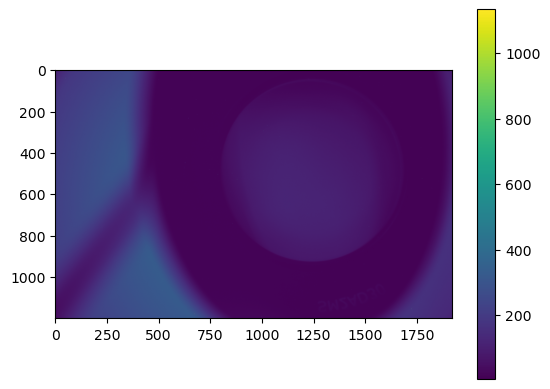

In [29]:
file = h5py.File('CLARA_experiments/YAGS/images/250Q_1.hdf', 'r')
# file.visit()
# file.close()|
plt.imshow(file['Capture000001'])
plt.colorbar()

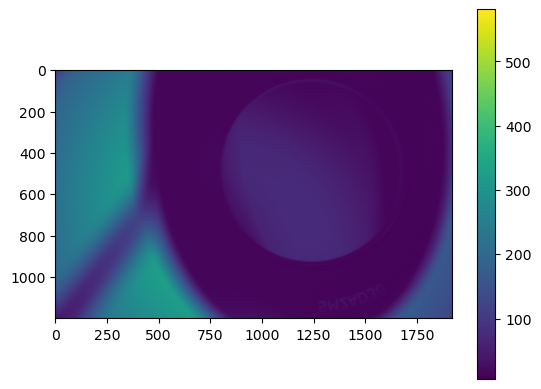

In [33]:
background = h5py.File('CLARA_experiments/YAGS/images/Background_200Q.hdf', 'r')
background_arr = np.array(background['Capture000001'])
plt.imshow(background_arr)
plt.colorbar()

In [24]:


background = h5py.File(
    'CLARA_experiments/YAGS/images/Background_200Q.hdf',
    'r'
)

keys = sorted(background.keys())

# Stack into (N, H, W)
images = np.stack([np.array(background[k]) for k in keys], axis=0)

# --- 1. Compute per-pixel variation ---
# max difference across images for each pixel
pixel_max = np.max(images, axis=0)
pixel_min = np.min(images, axis=0)
pixel_variation = pixel_max - pixel_min  # shape (H, W)

# --- 2. Find top 10 most varying pixels ---
flat_idx = np.argsort(pixel_variation.ravel())[::-1][:30]

h, w = pixel_variation.shape
top_pixels = [(idx // w, idx % w) for idx in flat_idx]

print("\nTop 10 most varying pixels (row, col, variation):")
for (r, c) in top_pixels:
    print(f"({r}, {c}) -> {pixel_variation[r, c]}")


Top 10 most varying pixels (row, col, variation):
(553, 326) -> 50
(1093, 551) -> 50
(366, 329) -> 49
(593, 275) -> 47
(360, 342) -> 47
(554, 296) -> 47
(1117, 605) -> 47
(481, 286) -> 46
(550, 340) -> 46
(544, 338) -> 46
(489, 286) -> 45
(383, 237) -> 45
(1055, 489) -> 45
(1059, 383) -> 45
(1024, 480) -> 45
(1080, 547) -> 45
(463, 312) -> 45
(953, 449) -> 45
(469, 288) -> 44
(1110, 598) -> 44
(1116, 436) -> 44
(486, 352) -> 44
(465, 299) -> 44
(1104, 527) -> 44
(557, 171) -> 44
(1102, 448) -> 44
(606, 330) -> 44
(1061, 458) -> 44
(942, 399) -> 44
(292, 223) -> 43


In [20]:
print("\nDetails for top varying pixels:")

for (r, c) in top_pixels:
    values = images[:, r, c]
    
    i_min = np.argmin(values)
    i_max = np.argmax(values)
    
    print(f"\nPixel ({r}, {c}):")
    print(f"  Variation: {values[i_max] - values[i_min]}")
    print(f"  Min: {values[i_min]} ({keys[i_min]})")
    print(f"  Max: {values[i_max]} ({keys[i_max]})")


Details for top varying pixels:

Pixel (1025, 1130):
  Variation: 292
  Min: 12 (Capture000004)
  Max: 304 (Capture000020)

Pixel (693, 648):
  Variation: 242
  Min: 14 (Capture000007)
  Max: 256 (Capture000020)

Pixel (478, 1581):
  Variation: 218
  Min: 13 (Capture000009)
  Max: 231 (Capture000017)

Pixel (480, 1577):
  Variation: 197
  Min: 16 (Capture000001)
  Max: 213 (Capture000017)

Pixel (1023, 610):
  Variation: 149
  Min: 165 (Capture000017)
  Max: 314 (Capture000014)

Pixel (912, 1187):
  Variation: 115
  Min: 65 (Capture000017)
  Max: 180 (Capture000016)

Pixel (692, 648):
  Variation: 104
  Min: 14 (Capture000001)
  Max: 118 (Capture000020)

Pixel (847, 159):
  Variation: 77
  Min: 147 (Capture000017)
  Max: 224 (Capture000013)

Pixel (485, 1578):
  Variation: 76
  Min: 16 (Capture000001)
  Max: 92 (Capture000017)

Pixel (705, 1468):
  Variation: 67
  Min: 53 (Capture000005)
  Max: 120 (Capture000012)

Pixel (1025, 1131):
  Variation: 62
  Min: 13 (Capture000008)
  Max: 7

In [25]:
import h5py
import numpy as np
from pathlib import Path

data_dir = Path("CLARA_experiments/YAGS/images")
file_paths = sorted(data_dir.glob("Background_*.hdf"))

if not file_paths:
    raise FileNotFoundError("No Background_*.hdf files found")

print(f"Found {len(file_paths)} files")

all_images = []
image_meta = []  # (file, dataset)

# ----------------------------
# Load all images
# ----------------------------
for file_path in file_paths:
    with h5py.File(file_path, "r") as f:
        for key in sorted(f.keys()):
            img = np.array(f[key])
            all_images.append(img)
            image_meta.append((file_path.name, key))

images = np.stack(all_images, axis=0)

print(f"Total images: {images.shape[0]}")
print(f"Image shape: {images.shape[1:]}")

# ----------------------------
# 1) Pixel variation across ALL files
# ----------------------------
pixel_min = images.min(axis=0)
pixel_max = images.max(axis=0)
pixel_var = pixel_max - pixel_min

h, w = pixel_var.shape

flat_idx = np.argsort(pixel_var.ravel())[::-1][:10]

print("\nTop 10 most varying pixels across ALL files:")

for rank, idx in enumerate(flat_idx, 1):
    r = idx // w
    c = idx % w

    values = images[:, r, c]
    i_min = np.argmin(values)
    i_max = np.argmax(values)

    print(f"\n#{rank} pixel ({r}, {c})")
    print(f"  variation: {values[i_max] - values[i_min]}")
    print(f"  min: {values[i_min]} from {image_meta[i_min]}")
    print(f"  max: {values[i_max]} from {image_meta[i_max]}")

# ----------------------------
# 2) Compare FILES (important)
# ----------------------------
# Compute mean image per file
file_means = {}
for file_path in file_paths:
    imgs = []
    with h5py.File(file_path, "r") as f:
        for key in f.keys():
            imgs.append(np.array(f[key]))
    file_means[file_path.name] = np.mean(imgs, axis=0)

# Pick first file as reference
ref_name = file_paths[0].name
ref_img = file_means[ref_name]

print(f"\nReference file: {ref_name}")

file_diffs = []

for fname, img in file_means.items():
    diff = np.max(np.abs(img - ref_img))
    file_diffs.append((fname, diff))

file_diffs.sort(key=lambda x: x[1], reverse=True)

print("\nFile-to-file variation (based on mean images):")
for fname, diff in file_diffs:
    print(f"{fname}: {diff}")

# ----------------------------
# 3) Worst pixel per file (diagnostic)
# ----------------------------
print("\nWorst pixel variation inside each file:")

for file_path in file_paths:
    with h5py.File(file_path, "r") as f:
        imgs = [np.array(f[k]) for k in f.keys()]
        imgs = np.stack(imgs)

        var = np.max(imgs, axis=0) - np.min(imgs, axis=0)

        print(f"{file_path.name}: max pixel variation = {np.max(var)}")

Found 6 files
Total images: 110
Image shape: (1200, 1920)

Top 10 most varying pixels across ALL files:

#1 pixel (327, 1496)
  variation: 1229
  min: 23 from ('Background_250Q.hdf', 'Capture000012')
  max: 1252 from ('Background_250S_1.hdf', 'Capture000007')

#2 pixel (627, 1760)
  variation: 998
  min: 9 from ('Background_250Q.hdf', 'Capture000002')
  max: 1007 from ('Background_250S_1.hdf', 'Capture000006')

#3 pixel (442, 983)
  variation: 954
  min: 56 from ('Background_250B.hdf', 'Capture000018')
  max: 1010 from ('Background_250S_1.hdf', 'Capture000001')

#4 pixel (130, 603)
  variation: 850
  min: 11 from ('Background_200Q.hdf', 'Capture000009')
  max: 861 from ('Background_250S_1.hdf', 'Capture000006')

#5 pixel (294, 1611)
  variation: 832
  min: 9 from ('Background_250Q.hdf', 'Capture000005')
  max: 841 from ('Background_250S_1.hdf', 'Capture000002')

#6 pixel (1159, 490)
  variation: 763
  min: 285 from ('Background_250S_1.hdf', 'Capture000006')
  max: 1048 from ('Backgroun

In [27]:
threshold = 100

# Find pixels exceeding threshold
mask = pixel_var > threshold
coords = np.argwhere(mask)

print(f"Pixels with variation > {threshold}: {len(coords)}")

# Track responsibility
file_counts = {}

for (r, c) in coords:
    values = images[:, r, c]

    i_min = np.argmin(values)
    i_max = np.argmax(values)

    file_min = image_meta[i_min][0]
    file_max = image_meta[i_max][0]

    # Count both contributors
    file_counts[file_min] = file_counts.get(file_min, 0) + 1
    file_counts[file_max] = file_counts.get(file_max, 0) + 1

# Sort by most involved
sorted_counts = sorted(file_counts.items(), key=lambda x: x[1], reverse=True)

print("\nFiles contributing most to large variations:")
for fname, count in sorted_counts:
    print(f"{fname}: involved in {count} high-variation pixels")

Pixels with variation > 100: 307857

Files contributing most to large variations:
Background_250S_1.hdf: involved in 299021 high-variation pixels
Background_200S.hdf: involved in 134591 high-variation pixels
Background_200Q.hdf: involved in 121445 high-variation pixels
Background_250B.hdf: involved in 27691 high-variation pixels
Background_250Q_1.hdf: involved in 18588 high-variation pixels
Background_250Q.hdf: involved in 14378 high-variation pixels


In [28]:
import h5py
import numpy as np
from pathlib import Path

data_dir = Path("CLARA_experiments/YAGS/images")
file_paths = sorted(data_dir.glob("Background_*.hdf"))

bins = [30, 60]

print("\nPer-file pixel variation distribution (%):\n")

for file_path in file_paths:
    with h5py.File(file_path, "r") as f:
        # Load all images in this file
        imgs = np.stack([np.array(f[k]) for k in sorted(f.keys())])

    # Compute per-pixel variation within this file
    pixel_var = np.max(imgs, axis=0) - np.min(imgs, axis=0)

    total = pixel_var.size

    low = np.sum(pixel_var < bins[0])
    mid = np.sum((pixel_var >= bins[0]) & (pixel_var <= bins[1]))
    high = np.sum(pixel_var > bins[1])

    print(f"{file_path.name}:")
    print(f"  < 30   : {100*low/total:.2f}%")
    print(f"  30–60  : {100*mid/total:.2f}%")
    print(f"  > 60   : {100*high/total:.2f}%")
    print()


Per-file pixel variation distribution (%):

Background_200Q.hdf:
  < 30   : 99.05%
  30–60  : 0.95%
  > 60   : 0.00%

Background_200S.hdf:
  < 30   : 99.06%
  30–60  : 0.94%
  > 60   : 0.00%

Background_250B.hdf:
  < 30   : 99.08%
  30–60  : 0.92%
  > 60   : 0.00%

Background_250Q.hdf:
  < 30   : 99.09%
  30–60  : 0.91%
  > 60   : 0.00%

Background_250Q_1.hdf:
  < 30   : 99.08%
  30–60  : 0.92%
  > 60   : 0.00%

Background_250S_1.hdf:
  < 30   : 97.51%
  30–60  : 2.21%
  > 60   : 0.28%



In [29]:
# ----------------------------
# Combined across ALL files
# ----------------------------
all_imgs = []

for file_path in file_paths:
    with h5py.File(file_path, "r") as f:
        imgs = [np.array(f[k]) for k in sorted(f.keys())]
        all_imgs.extend(imgs)

all_imgs = np.stack(all_imgs)

# Per-pixel variation across ALL files
pixel_var_all = np.max(all_imgs, axis=0) - np.min(all_imgs, axis=0)

total = pixel_var_all.size

low = np.sum(pixel_var_all < 30)
mid = np.sum((pixel_var_all >= 30) & (pixel_var_all <= 60))
high = np.sum(pixel_var_all > 60)

print("\n=== OVERALL (all files combined) ===")
print(f"< 30   : {100*low/total:.2f}%")
print(f"30–60  : {100*mid/total:.2f}%")
print(f"> 60   : {100*high/total:.2f}%")


=== OVERALL (all files combined) ===
< 30   : 51.13%
30–60  : 24.15%
> 60   : 24.72%


In [6]:
bkg_mapping = {
    "200B.hdf": "Background_200S.hdf",  #background missing for 200B, using 200S instead
    "200Q.hdf": "Background_200Q.hdf",
    "200S.hdf": "Background_200S.hdf",
    "200SC.hdf": "Background_200S.hdf",
    "250B.hdf": "Background_250B.hdf",
    "250Q_1.hdf": "Background_250Q_1.hdf",
    "250Q.hdf": "Background_250Q.hdf",
    "250S_1.hdf": "Background_250S_1.hdf",
    "250S.hdf": "Background_250S_1.hdf",  # background missing for 250S thursday, using 250S_1 wednesday instead
    "250SC_1.hdf": "Background_250S_1.hdf", 
    "250SC.hdf": "Background_250S_1.hdf", # background missing for 250SC thursday, using 250S_1 wednesday instead
}

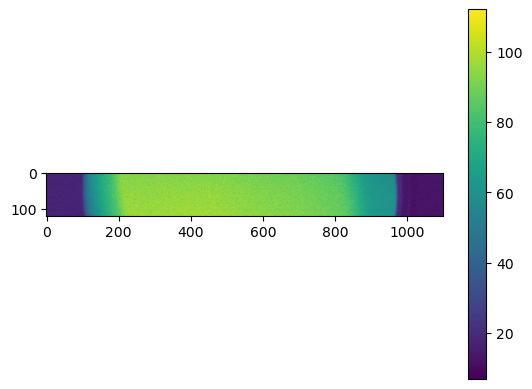

In [5]:
plt.imshow(background_arr[430:550, 700:1800])
plt.colorbar()

0.03170454545454545

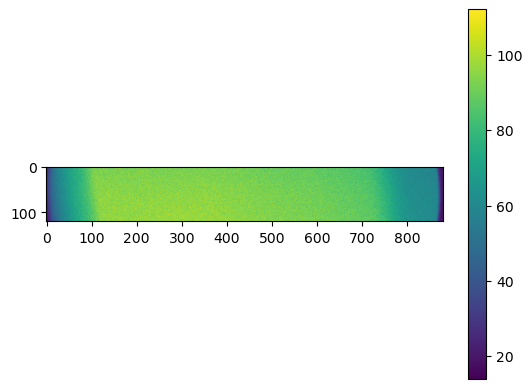

In [6]:
plt.imshow(background_arr[430:550, 800:1680])
plt.colorbar()
background_arr[430:550, 800:1680].shape #pixels for 27.9mm radius inner ring
pixel_calibration_YAG = 27.9/ (1680-800) #mm/pixel
pixel_calibration_YAG

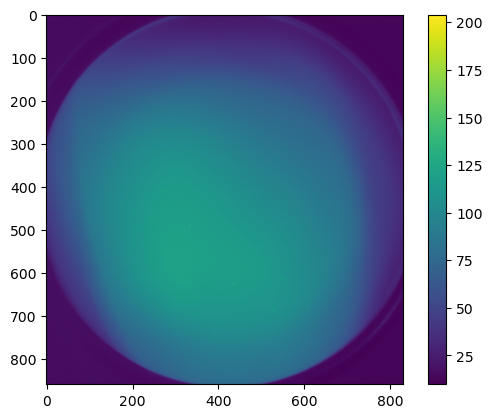

In [53]:
img1 = file['Capture000001']#[250:700,900:1650]
img1_arr = np.array(img1)
# combined = sum(file[key][250:700,900:1650] for key in file.keys())
average = sum(file[key][60:920,820:1650] for key in file.keys())/len(file.keys())
plt.imshow(average)
plt.colorbar()

In [8]:
background_arr 

array([[ 97, 110, 104, ...,  93,  92,  86],
       [104, 105, 105, ...,  86,  93,  92],
       [ 96, 101, 102, ..., 101,  93,  89],
       ...,
       [ 57,  60,  49, ..., 116, 119, 116],
       [ 60,  53,  52, ..., 115, 116, 120],
       [ 50,  50,  54, ..., 117, 115, 113]], dtype=uint16)

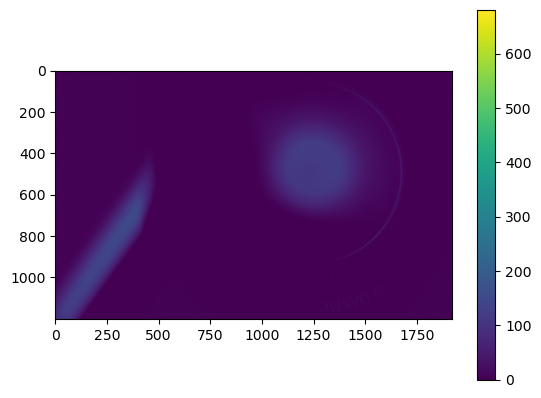

In [9]:
net_intensity = img1_arr.astype(np.int32) - background_arr.astype(np.int32)
net_intensity = np.clip(net_intensity, 0, None) #remove negative values
plt.imshow(net_intensity)
plt.colorbar()

In [4]:
plot_dose1(net_intensity[200:750,900:1600],"YAG")
# plot_dose11(average[250:700,1000:1550],"YAG")
pixel_calibration = 0.08467  # mm/pixel
y,x = np.arange(average[250:700,1000:1550].shape[0])* pixel_calibration_YAG, np.arange(average[250:700,1000:1550].shape[1])* pixel_calibration_YAG
# print(x,y)
# plot_dose(average[250:700,1000:1550],x,y,strip_width=5, centred=False)


NameError: name 'net_intensity' is not defined

In [ ]:

# def beam_area(img, fraction, center):
#     peak_val = np.nanmax(img)
#     threshold = fraction * peak_val

#     # mask of pixels above threshold
#     mask = img >= threshold

#     # keep image shape (better for geometry)
#     new_img = np.zeros_like(img)
#     new_img[mask] = img[mask]

#     # coordinates
#     y, x = np.indices(img.shape)

#     cy, cx = center
#     r = np.sqrt((x - cx)**2 + (y - cy)**2)

#     # mean radius of beam region
#     r_mean = np.mean(r[mask])

#     return new_img, r_mean

In [8]:
means = []
stds = []

for key in sorted(file.keys()): #guarantees they are processed in numerical order
    img = file[key][:]#[250:700, 900:1650]

    y, x = np.indices(img.shape)

    cx, cy = beam_centroid(img)

    # squared distance (faster than sqrt)
    r2 = (x - cx)**2 + (y - cy)**2

    R60 = beam_area(img, 0.6, cx, cy)

    mask = r2 <= R60**2

    mean_dose = np.nanmean(img[mask])
    std_dose = np.nanstd(img[mask])

    means.append(mean_dose)
    stds.append(std_dose)

TypeError: beam_area() takes 3 positional arguments but 4 were given

In [55]:
from pathlib import Path
import re
import csv

import h5py
import numpy as np
import matplotlib.pyplot as plt

input_dir = Path("CLARA_experiments/YAGs/images")
csv_path = Path("CLARA_experiments/yag_parameters.csv")

# bkg_mapping = {
#      "250SC_1.hdf": "Background_250S_1.hdf"} #background missing for 200B, using 200S instead
bkg_mapping = {
    "200B.hdf": "Background_200S.hdf",  #background missing for 200B, using 200S instead
    "200Q.hdf": "Background_200Q.hdf",
    "200S.hdf": "Background_200S.hdf",
    "200SC.hdf": "Background_200S.hdf",
    "250B.hdf": "Background_250B.hdf",
    "250Q_1.hdf": "Background_250Q_1.hdf",
    "250Q.hdf": "Background_250Q.hdf",
    "250S_1.hdf": "Background_250S_1.hdf",
    "250S.hdf": "Background_250S_1.hdf",  # background missing for 250S thursday, using 250S_1 wednesday instead
    "250SC_1.hdf": "Background_250B.hdf", 
    "250SC.hdf": "Background_250B.hdf", # background missing for 250SC thursday, using 250B wednesday instead
}
hdf_files = []
for fname in bkg_mapping.keys():
    path = input_dir / fname
    if path.exists():
        hdf_files.append(path)
    else:
        print(f"Missing file: {fname}")

done = set()
if csv_path.exists() and csv_path.stat().st_size > 0: #if csv file exists and is not empty, read existing entries to avoid reprocessing
    with open(csv_path, "r", newline="") as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            if len(row) >= 2:
                done.add((row[0], row[1]))

write_header = not csv_path.exists() or csv_path.stat().st_size == 0 #only write header if file doesn't exist or is empty





with open(csv_path, "a", newline="") as f:
    writer = csv.writer(f)

    if write_header:
        writer.writerow([
            "filename", "shot",
            "cx", "cy",
            "P_x", "P_y",
            "r90_x", "r90_y",
            "ratio_x", "ratio_y"
        ])

    for file_path in hdf_files:
        filename = file_path.name
        saved_first_fig = False

#background averaging
        try:
            bkg_name = bkg_mapping.get(filename)
            if bkg_name is None:
                print(f"No background mapping for {filename}")
                continue

            bkg_path = input_dir / bkg_name
            if not bkg_path.exists():
                print(f"Missing background file: {bkg_name}")
                continue

            bkg_file = h5py.File(bkg_path, 'r')
            bkg_avg = sum(bkg_file[key][60:920,820:1650] for key in bkg_file.keys())/len(bkg_file.keys())
            bkg_avg = np.flipud(bkg_avg.astype(np.float32))

            with h5py.File(file_path, "r") as img_file:
                for shot_key in img_file.keys():
                    key = (filename, shot_key)
                    if key in done:
                        print(f"Skipping already processed {key}")
                        continue

                    fig = None
                    try:
                        img = np.array(img_file[shot_key][60:920,820:1650], dtype=np.float32)
                        img = np.flipud(img)

                        if img.shape != bkg_avg.shape:
                            raise ValueError(f"Shape mismatch: {img.shape} vs {bkg_avg.shape}")

                        # img = np.clip(img - bkg_avg, 0, None)
                        img = img - bkg_avg

                        max_val = np.max(img)
                        if max_val == 0:
                            print(f"Zero max image after subtraction in {filename} {shot_key}")
                            continue

                        fig, cx, cy, Px, Py, r90_x, r90_y, ratio_x, ratio_y = plot_dose1(
                            img / max_val, "YAG"
                        )
                        if not saved_first_fig:
                            fig.savefig(f"CLARA_experiments/CLARA_output_figs/{filename}_{shot_key}.png",  bbox_inches="tight")
                            saved_first_fig = True

                        if not (1 <= Px <= 7 and 1 <= Py <= 7 and 3 <= r90_x <= 20 and 3 <= r90_y <= 20):
                            print(f"Rejected (bad fit) {filename} {shot_key}, Px = {Px}, Py = {Py}, r90_x = {r90_x}, r90_y = {r90_y}")
                            continue

                        writer.writerow([
                            filename, shot_key,
                            cx, cy,
                            Px, Py,
                            r90_x, r90_y,
                            ratio_x, ratio_y
                        ])
                        f.flush()

                    except Exception as e:
                        print(f"Failed on {filename} {shot_key}: {e}")

                    finally:
                        if fig is not None:
                            plt.close(fig)
                        plt.close("all")

        except Exception as e:
            print(f"Failed to process {filename}: {e}")
            continue

Rejected (bad fit) 200B.hdf Capture000001, Px = 0.6859311689911742, Py = 1.8505053227324415, r90_x = 1530.2588087559072, r90_y = 5.30239121143105
Rejected (bad fit) 200B.hdf Capture000002, Px = 0.7001796798778335, Py = 1.8591653404818864, r90_x = 1196.0937355383558, r90_y = 5.3252382315735405
Rejected (bad fit) 200B.hdf Capture000003, Px = 0.686830221878172, Py = 1.8521938043270492, r90_x = 1644.5409178829773, r90_y = 5.291456844534356
Rejected (bad fit) 200B.hdf Capture000004, Px = 0.6936432495441923, Py = 1.8848528887026264, r90_x = 1566.4983208041153, r90_y = 5.355653133607427
Rejected (bad fit) 200B.hdf Capture000005, Px = 0.6894297361687216, Py = 1.864985090812889, r90_x = 1552.1490027594423, r90_y = 5.325374576103146
Rejected (bad fit) 200B.hdf Capture000006, Px = 0.6877408432109188, Py = 1.8638992332095137, r90_x = 1588.0667301257754, r90_y = 5.325867248517274
Rejected (bad fit) 200B.hdf Capture000007, Px = 0.6984522194871814, Py = 1.8625181037936065, r90_x = 1285.7501664086305,

In [9]:

masked_img = np.zeros_like(img)
masked_img[mask] = img[mask]

# plt.imshow(masked_img)
plt.imshow(img)
plt.contour(mask, colors='white')

NameError: name 'mask' is not defined

uint16
(3659, 4950, 3)
3242 65535


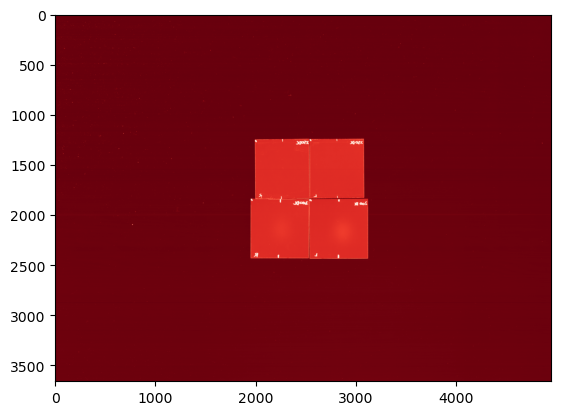

In [3]:
channel = 0
if channel == 1:
    cmap = 'Greens'

elif channel ==0:
    cmap = "Reds"

arr = tiff.imread("CLARA_experiments/CLARA_films/Film Scans/DC/CLARA_DC_250_200_MeV_2026_12_03.tif")
print(arr.dtype)
print(arr.shape)
print(arr.min(), arr.max())
plt.imshow(arr[:,:,channel],cmap=cmap)

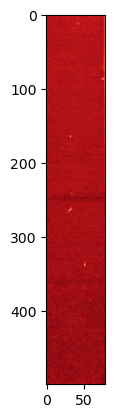

In [4]:
film_no_dose = tiff.imread("CLARA_experiments/CLARA_films/Film Scans/DC/CLARA_DC_250_200_MeV_2026_12_03.tif")
plt.imshow(film_no_dose[1300:1800,3000:3080,channel],cmap = cmap)#strip of top right film right 



(46955, 3242)

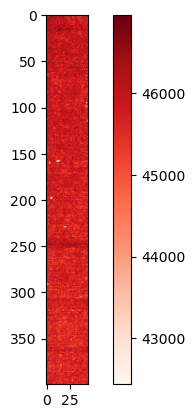

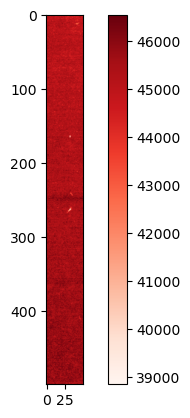

In [5]:
plt.imshow(film_no_dose[1300:1700,2005:2050,channel],cmap=cmap) #strip of top left film left
plt.colorbar()
plt.figure()
plt.imshow(film_no_dose[1300:1800,3000:3050,channel],cmap = cmap) #strip of top right film right 
plt.colorbar()
np.max(film_no_dose[1300:1700,2005:2050,channel]), np.min(film_no_dose)

45743.0


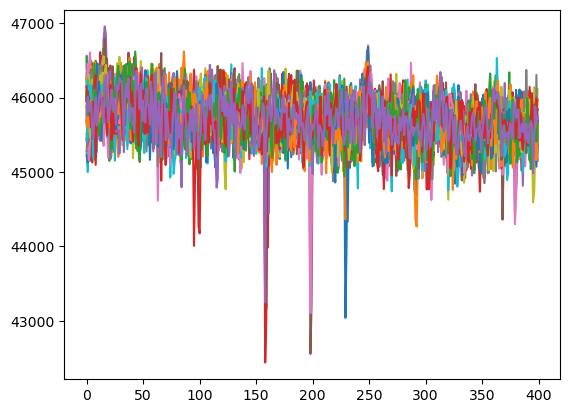

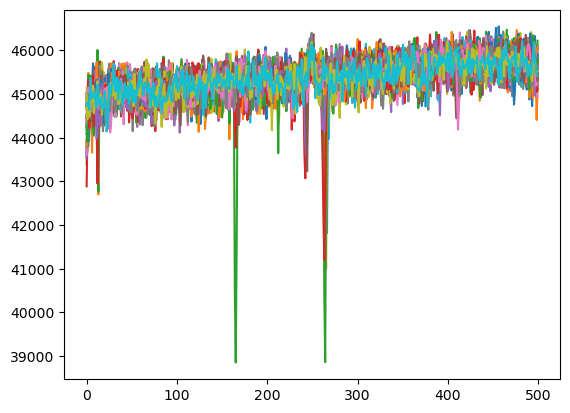

In [6]:
plt.plot(film_no_dose[1300:1700,2005:2050,channel])#right strip
print(np.median(film_no_dose[1300:1700,2005:2050,channel]))
plt.figure()
plt.plot(film_no_dose[1300:1800,3000:3050,channel]) #left strip

In [7]:
OD0_green = -np.log(np.median(film_no_dose[1300:1700,2005:2010,1])/65535)
OD0_red = -np.log(np.median(film_no_dose[1300:1700,2005:2010,0])/65535)
OD0_green,OD0_red

(0.41037528937056844, 0.35893364827233415)

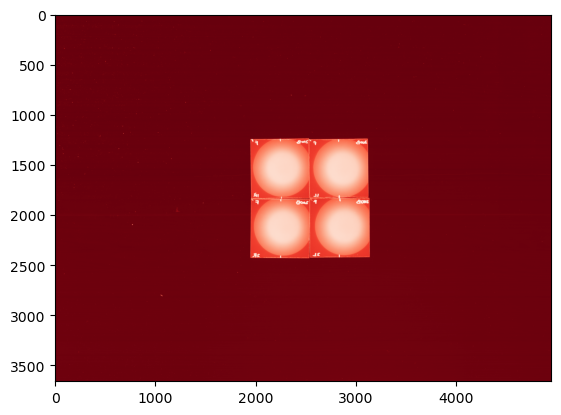

In [8]:
filename = 'CLARA_200B_F_2026_12_03'
films = tiff.imread(f"CLARA_experiments/CLARA_films/Film Scans/200B/{filename}.tif")
#("CLARA_experiments/CLARA_films/Film Scans/250S/CLARA_250S_B_2026_12_03.tif")
plt.imshow(films[:,:,channel],cmap = cmap)
# films.show()  # display image
# flipped_h = films.transpose(Image.FLIP_LEFT_RIGHT)

film_array = np.array(films)

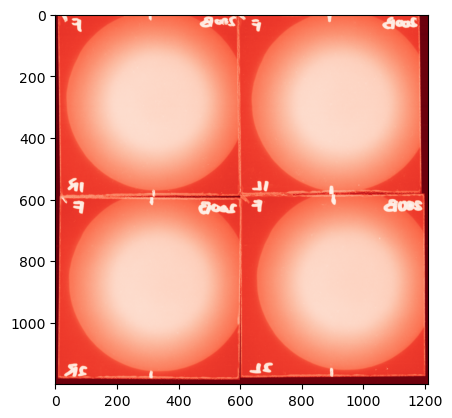

In [9]:
plt.imshow(film_array[1250:2450,1940:3150,channel],cmap=cmap)

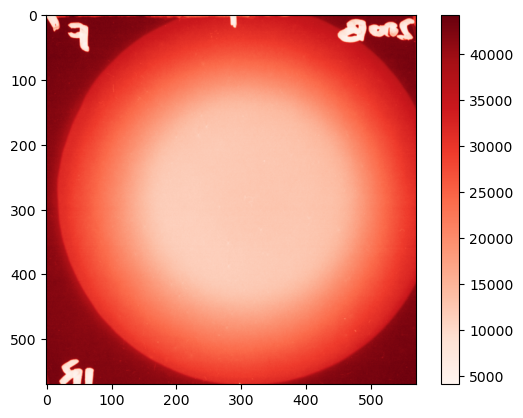

In [10]:
film1 = film_array[1250:1820,1960:2530,channel]
film2 = film_array[1250:1820,2560:3120,channel]
film3 = film_array[1850:2420,1960:2520,channel]
film4 = film_array[1840:2420,2550:3130,channel]



plt.imshow(film1,cmap=cmap)
plt.colorbar()


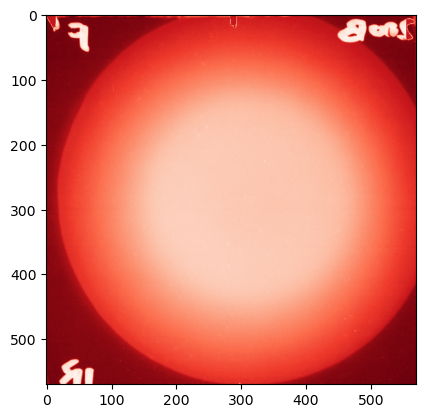

In [12]:
# removing low pixel values in corners and strip regions (from marker labeling)

h, w = film1.shape[:2]
corner_h = 70
corner_w = 15
mask = np.zeros((h, w), dtype=bool)
mask[:corner_h, :corner_w] = True
mask[:30, w//2-10:w//2+10] = True
mask[:corner_h, w-corner_w:] = True
mask[h-corner_h:, :corner_w] = True
mask[h-corner_h:, w-corner_w:] = True

film1[(mask) & (film1 < 12000)] = 35000
plt.imshow(film1,cmap=cmap)

In [ ]:
# np.save(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film1.npy', film1)
# np.save(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film2.npy', film2)
# np.save(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film3.npy', film3)
# np.save(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film4.npy', film4)

In [137]:
def dose_CLARA(PV,nOD0, channel):
    if channel ==0:
        a, b, c = 3.27, 16.9, -3.28
    elif channel ==1:
        a, b, c = 8.2, 10.9, -8.2
    elif channel ==2:
        a, b, c = 21.0, 14.0, -21.0

    OD = -np.log(PV/65535)
    nOD = OD - nOD0

    return a * (b*nOD) + c



In [138]:
print(dose_CLARA(film1, OD0_red, channel))



[[74.43619688 76.30117272 78.12105179 ... 13.83875128 15.60099543
  14.02489761]
 [75.74981051 78.40813296 80.02570209 ... 18.2797912  14.49650766
  13.71500116]
 [72.43303524 79.68478183 80.18552084 ... 17.25996564 13.70813427
  13.11395782]
 ...
 [ 0.9718862   1.38788302  0.67277705 ... -2.62222031 -2.46359125
  -2.63243883]
 [ 1.81810841  1.44835334  1.2287777  ... -3.44889221 -3.11059005
  -3.06498829]
 [ 2.02892498  1.28358987  1.81810841 ... -3.94002188 -3.18650947
  -2.8465923 ]]


In [139]:
film1.min(), film1.max()

(np.uint16(4052), np.uint16(44305))

1.0 -0.048396788723853675


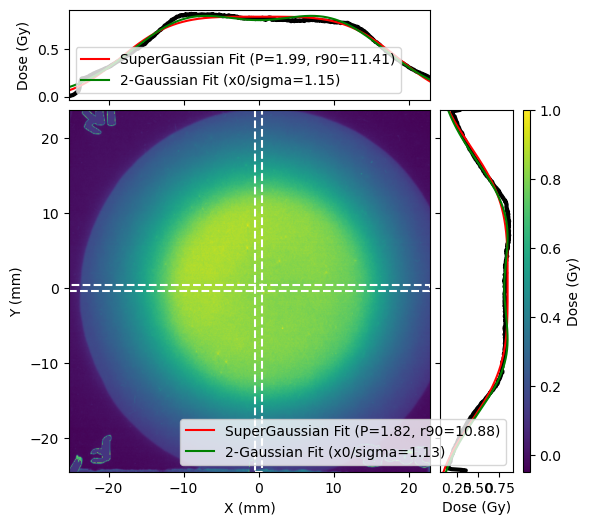

In [157]:
dose_rel = dose_CLARA(film1, OD0_red, channel)/np.max(dose_CLARA(film1, OD0_red, channel))
plot_dose1(dose_rel,"RCF")
print((dose_rel).max(), (dose_rel).min())

In [89]:
def dose_CLEAR(PV, nOD0, channel):
    if channel == 0:
        a, b, c = 4.6093, 0.1574, 4.6606
    elif channel == 1:
        a, b, c = 7.9162, 0.0418, 7.9213
    elif channel == 2:
        a, b, c = 23.5294, 0.1614, 23.2037

    # if channel == 0:
    #      a, b, c = 4.5211, 0.1609, 4.5522
    # elif channel == 1:
    #     a, b, c = 7.9284, 0.0414, 7.9364
    # elif channel == 2:
    #     a, b, c = 24.0703, 0.1513, 23.7625



    OD = -np.log(PV / 65535)
    nOD = OD - nOD0

    exp_term = np.exp(-nOD)
    return (a - c * exp_term) / (exp_term - b)


print(dose_CLEAR(film1, OD0_red, channel))
print((dose_CLEAR(film1, OD0_red, channel)).max(), (dose_CLEAR(film1, OD0_red, channel)).min())

[[45.68376547 51.34178471 57.98696937 ...  2.46010735  2.76037005
   2.49111108]
 [49.56156445 59.15894424 66.53560973 ...  3.24732413  2.57040401
   2.43958711]
 [40.59749598 64.86148451 67.34477428 ...  3.05740716  2.43845056
   2.34094477]
 ...
 [ 0.66137951  0.71036371  0.62648403 ...  0.25931569  0.27629383
   0.25822434]
 [ 0.76158353  0.71752833  0.69156635 ...  0.17193069  0.20747117
   0.21228514]
 [ 0.78689232  0.69803332  0.76158353 ...  0.12087087  0.19946901
   0.23541721]]
11334.437333009831 -499148.30585105735


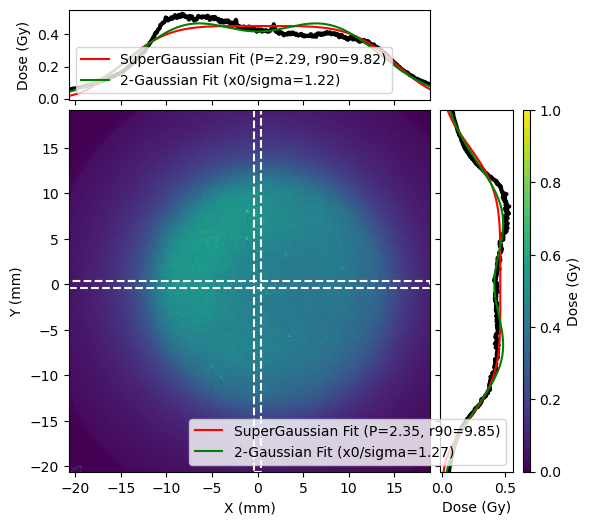

In [158]:
plot_dose1(dose_CLEAR(film1[50:-50,50:-50], OD0_red, channel)/np.max(dose_CLEAR(film1[50:-50,50:-50], OD0_red, channel)),"RCF")

In [56]:
def dose_CLEAR_poly(PV, nOD0, channel):
    
    # Polynomial coefficients (p4 → p0)
    if channel == 0:  # red
        coeffs = [9.56465954, -10.0096134, 10.1602326, 4.12083547, 0.00726233]
    elif channel == 1:  # green
        coeffs = [1.46014808, 0.98750624, 4.57336183, 8.33547864, -0.01277002]
    elif channel == 2:  # blue
        coeffs = [129.62111299, -72.99599522, 30.51809185, 28.99559952, 0.33870407]
    else:
        raise ValueError("channel must be 0 (red), 1 (green), or 2 (blue)")

    # Convert to OD → nOD
    OD = -np.log(PV / 65535)
    nOD = OD - nOD0

    # Evaluate polynomial
    return np.polyval(coeffs, nOD)

print(dose_CLEAR_poly(film1, OD0_red, channel))
print((dose_CLEAR_poly(film1, OD0_red, channel)).max(), (dose_CLEAR_poly(film1, OD0_red, channel)).min())

[[39.17860519 42.22348379 45.39681185 ...  2.44789037  2.74988304
   2.4791309 ]
 [41.30194445 45.91629416 48.94286476 ...  3.23706191  2.55896889
   2.42720615]
 [36.1295668  48.29072544 49.25124147 ...  3.04741397  2.42606036
   2.32769646]
 ...
 [ 0.64166229  0.68885462  0.60824487 ...  0.27029342  0.28522832
   0.26933623]
 [ 0.73852433  0.69578325  0.67070744 ...  0.194795    0.22521328
   0.22936459]
 [ 0.76317944  0.67694559  0.73852433 ...  0.15184089  0.21832881
   0.24941248]]
257.53281936305376 0.1518408944265716


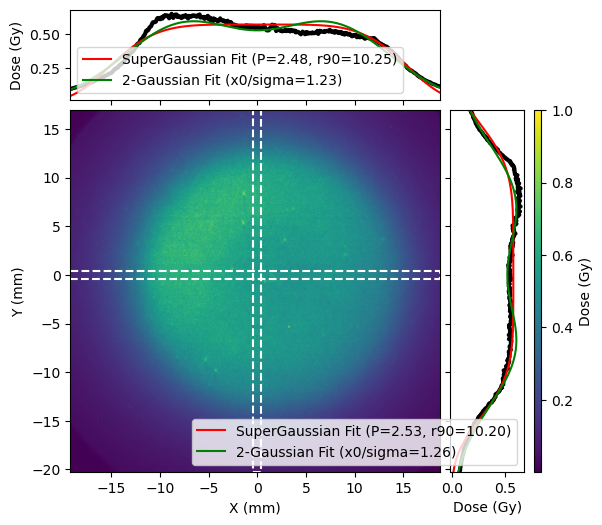

In [159]:
plot_dose1(dose_CLEAR_poly(film1[50:-80,70:-50], OD0_red, channel)/np.max(dose_CLEAR_poly(film1[50:-80,70:-50], OD0_red, channel)),"RCF")

checking code with CLEAR HUG films

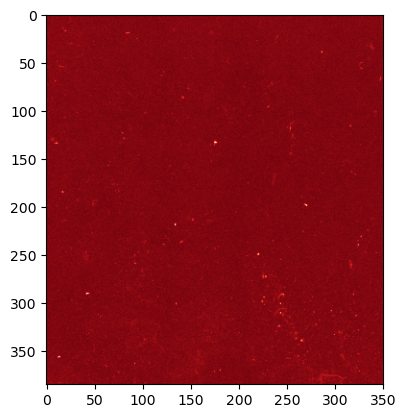

In [105]:
film_no_dose = tiff.imread("ZFE_28_10_2025_24h/J_035.tif")
plt.imshow(film_no_dose[50:-50, 30:-40, channel], cmap = cmap)

In [106]:

OD0_green = -np.log(np.median(film_no_dose[50:-50, 30:-40, 1])/65535)
OD0_red = -np.log(np.median(film_no_dose[50:-50, 30:-40, 0])/65535)
OD0_green,OD0_red

(np.float64(0.42962741958434625), np.float64(0.40343010071779056))

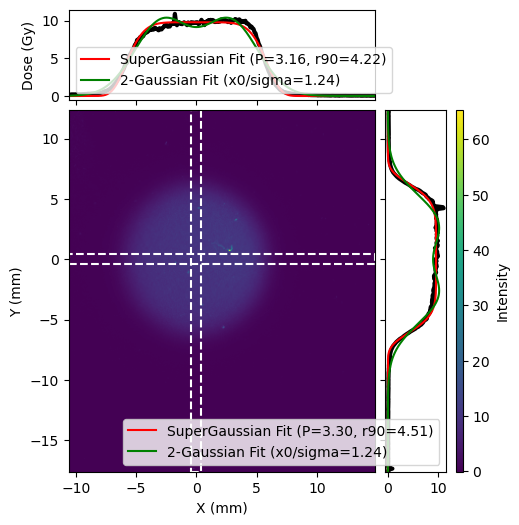

In [109]:
film_dummy = np.array(tiff.imread("ZFE_28_10_2025_24h/F_001.tif"))
plot_dose1(dose_CLEAR_poly(film_dummy[50:-80,70:-50,channel], OD0_red, channel),"RCF")

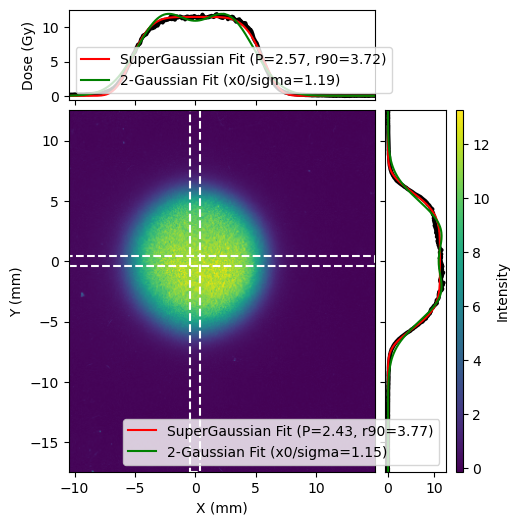

In [111]:
film_dummy = np.array(tiff.imread("ZFE_28_10_2025_24h/F_009.tif"))
plot_dose1(dose_CLEAR(film_dummy[50:-80,70:-50,channel], OD0_red, channel),"RCF")

In [4]:
charge1 = h5py.File('CLARA_experiments/YAGS/charge/ChargeMeasurement_2026-03-05T150855.114326.hdf5', 'r')

In [11]:
charge1['measurement']['charge']

<HDF5 group "/measurement/charge" (3 members)>

In [12]:

with h5py.File("CLARA_experiments/YAGS/charge/ChargeMeasurement_2026-03-05T150855.114326.hdf5", "r") as f:
    def print_structure(name, obj):
        print(name, type(obj))
    
    f.visititems(print_structure)

measurement <class 'h5py._hl.group.Group'>
measurement/camera <class 'h5py._hl.group.Group'>
measurement/camera/CLA-USR-DIA-CAM-01 <class 'h5py._hl.group.Group'>
measurement/camera/CLA-USR-DIA-CAM-01/ANA_CovXYPix_RBV <class 'h5py._hl.group.Group'>
measurement/camera/CLA-USR-DIA-CAM-01/ANA_CovXYPix_RBV/buffer <class 'h5py._hl.dataset.Dataset'>
measurement/camera/CLA-USR-DIA-CAM-01/ANA_CovXYPix_RBV/timestamps <class 'h5py._hl.dataset.Dataset'>
measurement/camera/CLA-USR-DIA-CAM-01/ANA_CovXYPix_RBV/value <class 'h5py._hl.dataset.Dataset'>
measurement/camera/CLA-USR-DIA-CAM-01/ANA_CovXY_RBV <class 'h5py._hl.group.Group'>
measurement/camera/CLA-USR-DIA-CAM-01/ANA_CovXY_RBV/buffer <class 'h5py._hl.dataset.Dataset'>
measurement/camera/CLA-USR-DIA-CAM-01/ANA_CovXY_RBV/timestamps <class 'h5py._hl.dataset.Dataset'>
measurement/camera/CLA-USR-DIA-CAM-01/ANA_CovXY_RBV/value <class 'h5py._hl.dataset.Dataset'>
measurement/camera/CLA-USR-DIA-CAM-01/ANA_EnableCallbacks <class 'h5py._hl.group.Group'>
m

In [23]:
with h5py.File("CLARA_experiments/YAGS/charge/ChargeMeasurement_2026-03-05T150855.114326.hdf5", "r") as f:
    ds = f["measurement/camera/CLA-USR-DIA-CAM-01/CAM_ArrayRate_RBV/value"]
    print("shape:", ds.shape)   # likely ()
    print("dtype:", ds.dtype)
    print("value:", ds[()])

shape: ()
dtype: float64
value: 10.0
